# NLP Workshop: Text EDA, Classification & Beyond

In this workshop you will practice the full NLP pipeline — text EDA, preprocessing, classification, similarity, topic modelling, and sentiment — on real data, while collaborating through Git.

You work in **groups of 3**. Some parts you do together on `main`; some you split across branches and merge through Pull Requests. Along the way you will hit a notebook merge conflict on purpose, and learn how to resolve it without losing work.

**Default dataset:** `20newsgroups` (two categories — `sci.space` and `sci.med`), built into scikit-learn.
**Bonus track:** Swedish product reviews (`timpal0l/swedish_reviews`) — try the same pipeline on Swedish text and see what breaks.

---

**Difficulty markers**
- ⭐ Basic — everyone should complete these
- ⭐⭐ Intermediate — comfortable with scikit-learn
- ⭐⭐⭐ Challenge — stretch goals


---
## Part 0: Repository & Group Setup (~10 min)

1. **One member forks** this repository on GitHub.
2. **Add the other two as collaborators** in Settings → Collaborators.
3. **Everyone clones the same fork:**
   ```bash
   git clone https://github.com/<FORK-OWNER>/Workshop-NLP.git
   cd Workshop-NLP
   ```
4. Decide who will own each classifier branch in Part 4 (Naive Bayes / Logistic Regression / SVM).
5. Open this notebook and run the **Setup** cell below. Confirm everyone has all packages.


## Setup

Run this cell to import libraries and download the small NLTK resources we need. If a package is missing, install it with `pip install <package>` and re-run.


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
for resource in ['stopwords', 'wordnet', 'vader_lexicon']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation

import textstat
import joblib

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_colwidth', 120)

EN_STOP = set(stopwords.words('english'))
RNG = 42
print('Setup OK.')


Setup OK.


---
## Part 1: First Contact with the Text (~15 min)

**Do this together on `main`.** Before anything fancy, get oriented. How many documents? How are they labelled? What does one of them actually look like?


### Exercise 1.1 ⭐ — Load the dataset

Load the two categories `sci.space` and `sci.med` from `20newsgroups`. Store the texts and labels in a DataFrame. Strip headers, footers, and quoted replies (the `remove=` argument).

- How many documents do you have?
- Is the dataset balanced across the two classes?


In [4]:
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=['sci.space', 'sci.med'],
    remove=('headers', 'footers', 'quotes'),
)

df = pd.DataFrame({
    'text': newsgroups.data,
    'label': [newsgroups.target_names[label] for label in newsgroups.target],
})

print('Documents:', len(df))
print(df['label'].value_counts())


Documents: 1977
label
sci.med      990
sci.space    987
Name: count, dtype: int64


### Exercise 1.2 ⭐ — Read a few examples

Print 2–3 documents per class. Just read them. What do you notice — vocabulary differences, length, formatting noise, anything?


In [13]:
for label, group in df.groupby('label'):
    print(f"\n--- {label} ---")
    for i, text in enumerate(group['text'].head(5), 1):
        print(f"\nDocument {i} ({label}):\n")
        print(text[:1000])
        print("\n" + ("=" * 80))



--- sci.med ---

Document 1 (sci.med):






Cute anecdote, but hardly indicative of the population.  From the responses
I've received to that post (all from men, by the way) I get the impression
that unless a person is willing to drop down and masturbate whenever the
need or desire strikes, then that person is very hung up on sex.

With tv programs about "boobs" (Seinfeld) and "masturbation (again Seinfeld)
and with condoms being handed out in high schools and with the teenage
pregnancy rate and the high abortion rate here in the States, I would
not assume that we American's are frightened of sex.  Rather we are a bit
stupid about it.  Healthy sexuality does not require flamboyance or
promiscuity.  It requires responsibility.



Document 2 (sci.med):

[reply to keith@actrix.gen.nz (Keith Stewart)]
 
 
It would help if you (and anyone else asking for medical information on
some subject) could ask specific questions, as no one is likely to type
in a textbook chapter covering all aspect

### Exercise 1.3 ⭐⭐ — Language check

Real datasets often contain mixed languages, code, or non-text. Confirm the dataset is mostly English (with a sanity check or `langdetect` if you have it installed).

```python
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0
sample = df['text'].sample(50, random_state=RNG)
sample.apply(lambda t: detect(t[:500]) if t.strip() else 'empty').value_counts()
```

If `langdetect` is unavailable, use a heuristic: count documents whose text contains common English stopwords like "the", "is", "and".


In [15]:
# Try langdetect if available
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    sample = df['text'].sample(50, random_state=RNG)
    print("Language detection using langdetect:")
    print(sample.apply(lambda t: detect(t[:500]) if t.strip() else 'empty').value_counts())
except ImportError:
    print("langdetect not available. Using English stopword heuristic instead.\n")
    # Fallback: check for common English stopwords
    en_words = {'the', 'is', 'and', 'to', 'of', 'in', 'a', 'for', 'on', 'with'}
    def has_english(text):
        tokens = text.lower().split()
        count = sum(1 for t in tokens if t in en_words)
        return count > 0
    
    sample = df['text'].sample(50, random_state=RNG)
    english_count = sample.apply(has_english).sum()
    print(f"Documents with English stopwords: {english_count}/50")


langdetect not available. Using English stopword heuristic instead.

Documents with English stopwords: 49/50


---
## Part 2: Text EDA (~25 min)

**Do this together on `main`.** Text is rich and easy to misjudge — describe it before you model it.


### Exercise 2.1 ⭐ — Length distributions

Compute character count and word count for every document. Plot a histogram of word counts, coloured by class.

- Are the two classes similar in length?
- Are there extreme outliers? Should they worry you?


Character count stats:
           count         mean          std  min    25%    50%      75%  \
label                                                                    
sci.med    990.0  1309.617172  3466.242400  0.0  287.0  557.0  1105.75   
sci.space  987.0  1212.656535  3320.142697  0.0  246.5  505.0   994.00   

               max  
label               
sci.med    37332.0  
sci.space  56793.0  

Word count stats:
           count        mean         std  min    25%   50%     75%     max
label                                                                     
sci.med    990.0  200.125253  467.649991  0.0  48.25  92.0  183.75  4972.0
sci.space  987.0  189.907801  495.942080  0.0  42.00  85.0  164.00  9113.0


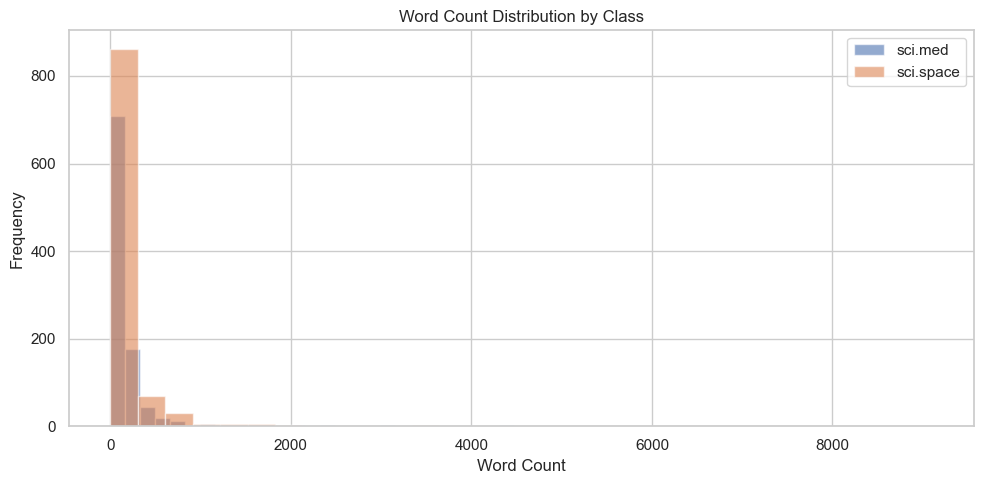


Documents with > 2000 words:
Total: 25 (1.3%)
label
sci.med      16
sci.space     9
Name: count, dtype: int64


In [16]:
# Compute character and word counts
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

# Print summary statistics
print("Character count stats:")
print(df.groupby('label')['char_count'].describe())
print("\nWord count stats:")
print(df.groupby('label')['word_count'].describe())

# Plot histogram of word counts by class
fig, ax = plt.subplots(figsize=(10, 5))
for label in df['label'].unique():
    subset = df[df['label'] == label]['word_count']
    ax.hist(subset, alpha=0.6, label=label, bins=30)

ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Distribution by Class')
ax.legend()
plt.tight_layout()
plt.show()

# Check for outliers
print("\nDocuments with > 2000 words:")
long_docs = df[df['word_count'] > 2000]
print(f"Total: {len(long_docs)} ({100*len(long_docs)/len(df):.1f}%)")
print(long_docs['label'].value_counts())


In [ ]:
# Your code here


### Exercise 2.2 ⭐ — Readability (Flesch Reading Ease)

Compute `textstat.flesch_reading_ease` for each document. Higher = easier to read.

- What is the median readability per class?
- Plot the distribution. Is `sci.med` measurably harder to read than `sci.space`?


Median Flesch Reading Ease by class:
label
sci.med      58.182470
sci.space    61.333333
Name: flesch, dtype: float64

Descriptive stats:
           count       mean        std        min        25%        50%  \
label                                                                     
sci.med    990.0  56.170627  18.531904 -25.690228  46.921863  58.182470   
sci.space  987.0  58.859520  19.879954 -91.295000  50.330417  61.333333   

                 75%      max  
label                          
sci.med    68.515960  116.145  
sci.space  70.945713  117.160  


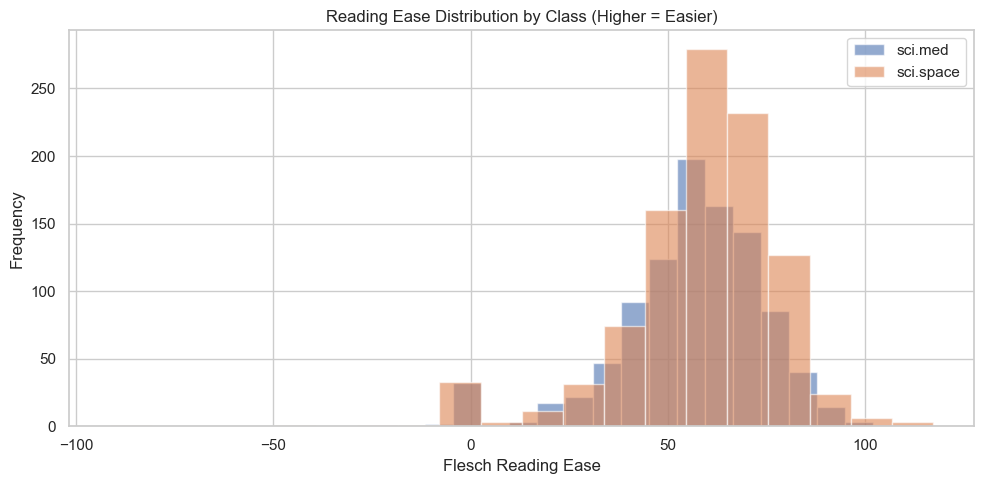


Median comparison: sci.space=61.3, sci.med=58.2
Difference: 3.2 points (positive means sci.space is easier)


In [17]:
# Compute Flesch Reading Ease for each document
df['flesch'] = df['text'].apply(textstat.flesch_reading_ease)

# Print median readability per class
print("Median Flesch Reading Ease by class:")
print(df.groupby('label')['flesch'].median())
print("\nDescriptive stats:")
print(df.groupby('label')['flesch'].describe())

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 5))
for label in df['label'].unique():
    subset = df[df['label'] == label]['flesch']
    ax.hist(subset, alpha=0.6, label=label, bins=20)

ax.set_xlabel('Flesch Reading Ease')
ax.set_ylabel('Frequency')
ax.set_title('Reading Ease Distribution by Class (Higher = Easier)')
ax.legend()
plt.tight_layout()
plt.show()

# Statistical comparison
med_space = df[df['label'] == 'sci.space']['flesch'].median()
med_med = df[df['label'] == 'sci.med']['flesch'].median()
print(f"\nMedian comparison: sci.space={med_space:.1f}, sci.med={med_med:.1f}")
print(f"Difference: {med_space - med_med:.1f} points (positive means sci.space is easier)")


### Exercise 2.3 ⭐⭐ — Vocabulary size and type-token ratio

For each class, compute:

- The number of **unique** lowercased tokens (vocabulary size).
- The **type-token ratio**: unique tokens ÷ total tokens. (Lower = more repetition.)

Hint: build per-class joined corpora first, then split.


In [18]:
# Build per-class joined corpora and compute vocabulary metrics
results = []

for label in df['label'].unique():
    # Join all documents for this class
    corpus = ' '.join(df[df['label'] == label]['text'])
    
    # Tokenize (lowercase, split on whitespace)
    tokens = corpus.lower().split()
    
    # Compute unique tokens
    unique_tokens = set(tokens)
    vocab_size = len(unique_tokens)
    total_tokens = len(tokens)
    
    # Compute type-token ratio
    ttr = vocab_size / total_tokens if total_tokens > 0 else 0
    
    results.append({
        'Class': label,
        'Vocabulary Size': vocab_size,
        'Total Tokens': total_tokens,
        'Type-Token Ratio': ttr
    })

results_df = pd.DataFrame(results)
print("Vocabulary Metrics by Class:")
print(results_df.to_string(index=False))
print("\nInterpretation:")
print("- Vocabulary Size: number of unique lowercased tokens")
print("- Type-Token Ratio: repetition indicator (lower = more repetition)")


Vocabulary Metrics by Class:
    Class  Vocabulary Size  Total Tokens  Type-Token Ratio
  sci.med            30301        198124          0.152940
sci.space            30105        187439          0.160612

Interpretation:
- Vocabulary Size: number of unique lowercased tokens
- Type-Token Ratio: repetition indicator (lower = more repetition)


### Exercise 2.4 ⭐⭐ — Top terms per class

Use `CountVectorizer(stop_words='english')` to count words per class. Plot the top 15 words for each class as a bar chart.

- Do the top words look discriminative?
- Are any of them obvious leakage (class name, dataset artefacts)?


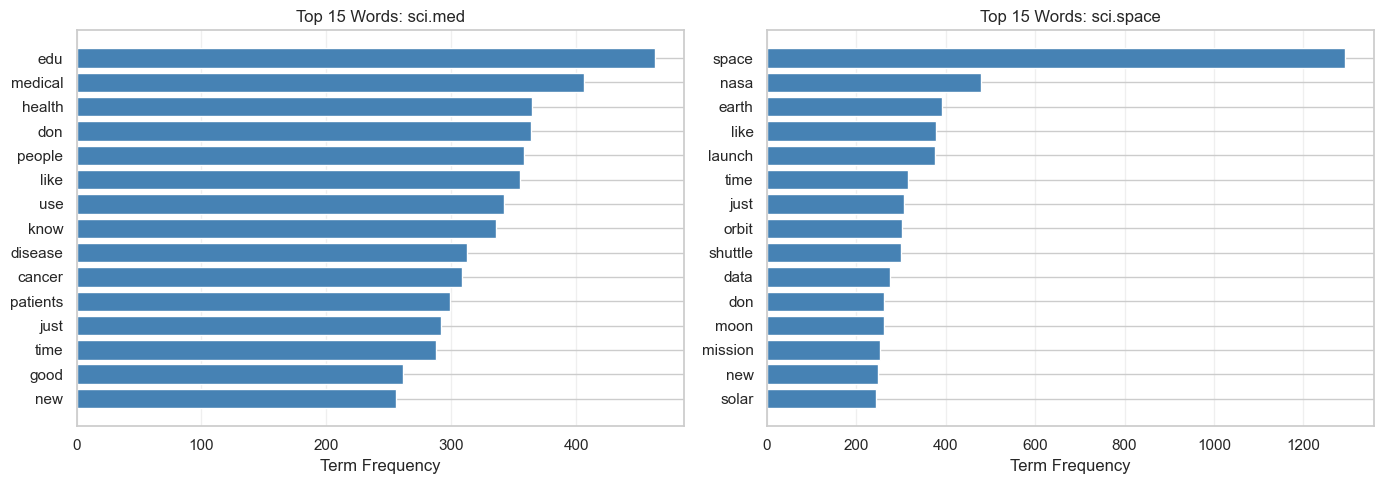

Top terms by class (discriminativeness analysis):

sci.med: edu, medical, health, don, people, like, use, know, disease, cancer, patients, just, time, good, new

sci.space: space, nasa, earth, like, launch, time, just, orbit, shuttle, data, don, moon, mission, new, solar


In [19]:
# Use CountVectorizer to count words per class
vec = CountVectorizer(stop_words='english', min_df=2)
term_doc_matrix = vec.fit_transform(df['text'])
feature_names = vec.get_feature_names_out()

# Get top 15 words per class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, label in enumerate(df['label'].unique()):
    # Sum counts for documents in this class
    class_mask = df['label'] == label
    class_counts = term_doc_matrix[class_mask].sum(axis=0).A1
    
    # Get top 15 terms
    top_indices = class_counts.argsort()[-15:][::-1]
    top_terms = feature_names[top_indices]
    top_counts = class_counts[top_indices]
    
    # Plot
    axes[idx].barh(range(len(top_terms)), top_counts, color='steelblue')
    axes[idx].set_yticks(range(len(top_terms)))
    axes[idx].set_yticklabels(top_terms)
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Term Frequency')
    axes[idx].set_title(f'Top 15 Words: {label}')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Discriminativeness check
print("Top terms by class (discriminativeness analysis):")
for label in df['label'].unique():
    class_mask = df['label'] == label
    class_counts = term_doc_matrix[class_mask].sum(axis=0).A1
    top_indices = class_counts.argsort()[-15:][::-1]
    top_terms = feature_names[top_indices]
    print(f"\n{label}: {', '.join(top_terms)}")


### Exercise 2.5 ⭐⭐⭐ — Keyword-in-context (KWIC)

Tuertscher et al. (2014) used words like *because, since, therefore, due to* as proxies for **justifications** in scientific text. Build a small KWIC helper:

- Given a target word, return the surrounding context (e.g. 5 words on each side).
- Show 5 occurrences of "because" across the corpus.

What can you learn from this that frequency counts alone hide?


In [20]:
# Build a KWIC (keyword-in-context) helper
def kwic(target_word, texts, context_window=5):
    """
    Extract keyword-in-context occurrences.
    
    Args:
        target_word: word to search for (case-insensitive)
        texts: list of documents to search
        context_window: number of words on each side
    
    Returns:
        List of (left_context, target, right_context, doc_index) tuples
    """
    target_word = target_word.lower()
    occurrences = []
    
    for doc_idx, text in enumerate(texts):
        tokens = text.lower().split()
        for i, token in enumerate(tokens):
            # Match word (allowing for punctuation)
            if target_word in token:
                start = max(0, i - context_window)
                end = min(len(tokens), i + context_window + 1)
                left = ' '.join(tokens[start:i])
                right = ' '.join(tokens[i+1:end])
                occurrences.append((left, token, right, doc_idx))
    
    return occurrences

# Find 5 occurrences of "because"
results = kwic('because', df['text'].tolist(), context_window=5)
print(f"Found {len(results)} occurrences of 'because'\n")
print("=" * 100)

for idx, (left, target, right, doc_idx) in enumerate(results[:5], 1):
    label = df.iloc[doc_idx]['label']
    print(f"\nOccurrence {idx} (from {label}):")
    print(f"  ... {left} >>> {target} <<< {right} ...")
    print()

print("=" * 100)
print("\nWhat KWIC reveals that frequency counts hide:")
print("- Context shows HOW words are used, not just that they appear")
print("- 'because' introduces justifications, explanations, or causal reasoning")
print("- Different fields may use justification markers differently (sci.med vs sci.space)")
print("- Word frequency alone doesn't capture semantic role or rhetorical structure")


Found 392 occurrences of 'because'


Occurrence 1 (from sci.space):
  ... at the rate it does >>> because <<< the space where it resides ...


Occurrence 2 (from sci.med):
  ... e.g.). this may make sense >>> because <<< vit. c is an antioxidant ...


Occurrence 3 (from sci.med):
  ... to the use of edta >>> because <<< it is not specific for ...


Occurrence 4 (from sci.med):
  ... chelation therapy has been used >>> because <<< of mineral imbalances that were ...


Occurrence 5 (from sci.med):
  ... partial. it is interesting medically >>> because <<< the normal location of organs ...


What KWIC reveals that frequency counts hide:
- Context shows HOW words are used, not just that they appear
- 'because' introduces justifications, explanations, or causal reasoning
- Different fields may use justification markers differently (sci.med vs sci.space)
- Word frequency alone doesn't capture semantic role or rhetorical structure


### 🔀 Git checkpoint — commit the shared foundation

Before branching, everyone should have the same starting point.

```bash
git add nlp_workshop.ipynb
git commit -m "Complete Parts 1–2: data loading and EDA"
git push origin main
```


---
## Part 3: Pre-processing (~20 min)

**Do this together on `main`.** Each step throws away information — that's the point. Watch the vocabulary shrink and ask yourself whether each step makes sense for *your* downstream task.


### Exercise 3.1 ⭐ — Lowercase + strip non-letters

Write a `clean_text` function that:

1. Lowercases the text.
2. Replaces anything that isn't a letter or whitespace with a space.
3. Collapses repeated whitespace.

Apply it to a column called `text_clean`.


In [ ]:
# Your code here


### Exercise 3.2 ⭐ — Stopword removal

Remove English stopwords from `text_clean` to produce `text_nostop`. Compare the average token count before and after — how much did you lose?


In [ ]:
# Your code here


### Exercise 3.3 ⭐⭐ — Stemming

Apply Porter stemming. Compare the vocabulary size of `text_nostop` vs the stemmed version.

- *running, runs, ran* — does Porter unify these?
- What does it get wrong (over-stemming)?


In [ ]:
# Your code here


### Exercise 3.4 ⭐⭐ — Lemmatization (WordNet)

Apply WordNet lemmatization to `text_nostop`. Compare against stemming.

- Which is more aggressive (smaller vocabulary)?
- Which produces real words?
- Which would you use, and why?


In [ ]:
# Your code here


### Exercise 3.5 ⭐⭐⭐ — Compare the funnel

Make a single bar chart showing the **vocabulary size at each stage**: raw → cleaned → no stopwords → stemmed → lemmatized.

When you finalize the column you will use downstream — pick *one* (`text_lemma` is a sensible default) and store it as `text_final`.


In [ ]:
# Your code here


---
## Part 3.5: Resolving notebook merge conflicts (~10 min)

**Why this matters.** A `.ipynb` is JSON. When two people edit the same cell on different branches and merge, plain `git merge` shows you raw JSON conflict markers — almost impossible to resolve correctly. Before the next part — where three of you will edit *this same notebook* on three different branches — set up `nbdime` so notebook diffs are readable.

### Step 1 — Configure `nbdime` (everyone, once per machine)

```bash
pip install nbdime
nbdime config-git --enable --global
```

This registers `nbdime` as the diff/merge driver for `.ipynb` files in every repo on your machine.

### Step 2 — (Optional but recommended) Strip outputs before commit

Notebook outputs (plots, numbers, execution counts) are the worst source of conflicts. Stripping them before commit eliminates ~80% of conflict noise:

```bash
pip install nbstripout
nbstripout --install
```

### Step 3 — Practice: create a conflict on purpose

Two members do this in parallel — *before* Part 4:

```bash
# Member A
git checkout -b conflict-demo-a
# Edit any markdown cell — change a sentence
git add nlp_workshop.ipynb
git commit -m "demo: edit by member A"

# Member B (from main, in parallel)
git checkout -b conflict-demo-b
# Edit the same markdown cell — change it differently
git add nlp_workshop.ipynb
git commit -m "demo: edit by member B"
```

Now merge B's branch into A's. You should get a conflict.

```bash
git checkout conflict-demo-a
git merge conflict-demo-b      # CONFLICT
nbdime mergetool                # opens a readable cell-level merge UI
```

Resolve, commit, then **delete both demo branches** before Part 4:

```bash
git branch -D conflict-demo-a conflict-demo-b
git push origin --delete conflict-demo-a conflict-demo-b   # if pushed
```

### Why this is essential

You are about to have three branches editing the same notebook. Without `nbdime` the merge in Part 5 will hurt; with `nbdime` it's a 30-second cell-by-cell choice.


---
## Part 4: Vectorize & Classify (~30 min)

### Branch out!

Each group member picks **one** classifier and creates a branch:

| Classifier | Branch | Vectorizer |
|------------|--------|-----------|
| Multinomial Naive Bayes | `experiment/countvec-nb` | `CountVectorizer` |
| Logistic Regression | `experiment/tfidf-logreg` | `TfidfVectorizer` |
| Linear SVM | `experiment/tfidf-svm` | `TfidfVectorizer` |

Work *only* in your section (4A / 4B / 4C). Leave the others empty — you will see them appear when your teammates' PRs are merged in Part 5.

```bash
git checkout main
git pull origin main
git checkout -b experiment/<your-classifier>
```


### Common: Train/test split (everyone runs this once)

Before splitting into branch-specific work, the group should agree on the same split. Run this on `main` first, then branch.


In [ ]:
# Stratified split so both classes appear in train AND test.
X_train, X_test, y_train, y_test = train_test_split(
    df['text_final'], df['label'],
    test_size=0.25, stratify=df['label'], random_state=RNG,
)
print(f'Train: {len(X_train)}  Test: {len(X_test)}')


### Exercise 4.0 ⭐ — Baseline (everyone)

Before any model, fit a `DummyClassifier(strategy='most_frequent')` and print its accuracy on the test set. **Anything below this number means your model is worse than guessing.** This is your floor.


In [ ]:
# Your code here


### 4A: CountVectorizer + Multinomial Naive Bayes

*Work on branch `experiment/countvec-nb`.*


#### Exercise 4A.1 ⭐ — Fit the model

Vectorize with `CountVectorizer(stop_words='english', min_df=2)` and fit `MultinomialNB`. Print test accuracy.


In [ ]:
# Your code here  (only on branch experiment/countvec-nb)


#### Exercise 4A.2 ⭐⭐ — Classification report + confusion matrix

Print `classification_report` and plot `ConfusionMatrixDisplay`. Which class is harder? Why?


In [ ]:
# Your code here


#### Exercise 4A.3 ⭐⭐ — Top predictive words

Naive Bayes exposes log-probabilities per class via `feature_log_prob_`. For each class, print the 15 most informative words (highest `log P(word | class) - log P(word | other class)`).


In [ ]:
# Your code here


#### Exercise 4A.4 ⭐⭐⭐ — Error analysis

Pick 5 documents where NB got it wrong. Print them. Why did the model miss?


In [ ]:
# Your code here


---
### 4B: TfidfVectorizer + Logistic Regression

*Work on branch `experiment/tfidf-logreg`.*


#### Exercise 4B.1 ⭐ — Fit the model

Vectorize with `TfidfVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))` and fit `LogisticRegression(max_iter=1000)`. Print test accuracy.

Why TF-IDF instead of raw counts? Why bigrams?


In [ ]:
# Your code here  (only on branch experiment/tfidf-logreg)


#### Exercise 4B.2 ⭐⭐ — Classification report + confusion matrix


In [ ]:
# Your code here


#### Exercise 4B.3 ⭐⭐ — Top predictive features

Logistic Regression exposes `coef_`. The most positive coefficients push toward class 1; most negative toward class 0. Print the 15 strongest features in each direction.


In [ ]:
# Your code here


#### Exercise 4B.4 ⭐⭐⭐ — Cross-validation

Run 5-fold cross-validation. Is the test-set number you reported a fluke or stable?


In [ ]:
# Your code here


---
### 4C: TfidfVectorizer + Linear SVM

*Work on branch `experiment/tfidf-svm`.*


#### Exercise 4C.1 ⭐ — Fit the model

Vectorize with `TfidfVectorizer(stop_words='english', min_df=2)` and fit `LinearSVC()`. Print test accuracy.


In [ ]:
# Your code here  (only on branch experiment/tfidf-svm)


#### Exercise 4C.2 ⭐⭐ — Classification report + confusion matrix


In [ ]:
# Your code here


#### Exercise 4C.3 ⭐⭐ — Top features

LinearSVC also has `coef_`. Print the 15 strongest features in each direction.


In [ ]:
# Your code here


#### Exercise 4C.4 ⭐⭐⭐ — Calibration vs Logistic Regression

`LinearSVC` does not expose probabilities. Wrap it in `CalibratedClassifierCV` and produce predicted probabilities. Compare to LR's probabilities on a few examples.


In [ ]:
# Your code here


### 🔀 Git checkpoint — push your experiment branch

```bash
git add nlp_workshop.ipynb
git commit -m "Complete experiment: <classifier>"
git push -u origin experiment/<classifier>
```

Then open a Pull Request from your branch to `main` on GitHub. Move on to Part 5 once everyone has pushed.


---
## Part 5: Pull Requests, Conflicts & Comparison (~15 min)

Now the collaborative part. Three PRs are open. Merge them one at a time:

1. **Merge the first PR** — clean. No conflicts.
2. **Pull `main` locally:** `git checkout main && git pull`.
3. **Merge the second PR** — likely a conflict. Use `nbdime mergetool` (you set this up in Part 3.5). Pick *both sets of cells* — they're in different sections of the notebook.
4. **Merge the third PR** — same drill.

Once `main` has all three classifiers merged, fill in the comparison table below.


### Exercise 5.1 ⭐ — Comparison table

Fill in this table from your three experiments:

| | NB (CountVec) | LogReg (TF-IDF) | SVM (TF-IDF) |
|---|---|---|---|
| Test accuracy | | | |
| Per-class F1 (sci.med) | | | |
| Per-class F1 (sci.space) | | | |
| Most striking error | | | |
| Words it relies on | | | |


### Exercise 5.2 ⭐⭐ — Disagreement analysis

Find documents where the three classifiers **disagree**. Print 3–5 of them.

- Are the disagreements on genuinely ambiguous documents, or is one model just wrong?
- Which model would you trust on the hard ones, and why?


In [ ]:
# Your code here


---
## Part 6: Topic Modelling & Similarity (~15 min)

**Group, on `main`.** Now an unsupervised view of the data — what would the topics look like if we *didn't* know the labels?


### Exercise 6.1 ⭐ — Cosine similarity (small sample)

Pick a sample of 20 documents. Compute the cosine similarity matrix on TF-IDF vectors. Plot it as a heatmap.

⚠️ Do **not** compute the full N×N matrix on all documents — it produces an unreadable plot and may freeze your kernel.


In [ ]:
# Your code here


### Exercise 6.2 ⭐⭐ — LDA topic modelling

Fit `LatentDirichletAllocation(n_components=4, random_state=RNG)` on **count-vectorized** features (LDA assumes integer counts; TF-IDF can work but is not the convention). Print the top 10 words per topic.

- Do the discovered topics align with the known labels (`sci.med` / `sci.space`)?
- Are some topics about something else (formatting noise, common headers)?


In [ ]:
# Your code here


### Exercise 6.3 ⭐⭐⭐ — Topic distribution per class

For each document, get its dominant topic. Cross-tabulate dominant topic × true label. Do the topics partition the classes cleanly?


In [ ]:
# Your code here


---
## Part 7: Sentiment & Quantification (~15 min)

**Group, on `main`.** Slide 20 made the bridge: text becomes a *number* you can feed into downstream analysis. Let's actually do that.


### Exercise 7.1 ⭐ — VADER sentiment

Score every document with VADER's compound score. Plot the distribution by class. Is one class systematically more negative? (For `sci.med` vs `sci.space` you might be surprised.)


In [ ]:
# Your code here


### Exercise 7.2 ⭐⭐ — Numeric features only

Train a classifier using **only** the numeric features you derived: `flesch`, `word_count`, `sentiment`. How well can you classify with no text vectorization at all?

This is the slide-20 idea in action: text → index → input to standard ML.


In [ ]:
# Your code here


### Exercise 7.3 ⭐⭐⭐ — Combined features

Combine TF-IDF text features with the three numeric features (use `scipy.sparse.hstack`). Does adding readability + sentiment beat pure TF-IDF?

Often the answer is "no" — and *that* is the interesting finding.


In [ ]:
# Your code here


---
## Part 8: Synthesis & Pipeline Hand-off (~10 min)

**Group, on `main`.** Wrap the winning model in a `Pipeline` and dump it. This is the artefact a Streamlit / Netlify app would load.


### Exercise 8.1 ⭐ — Build a Pipeline

Wrap your best vectorizer + classifier in a single `sklearn.pipeline.Pipeline`. Fit it on **all** training data. Test it on a hand-typed sentence:

```python
pipeline.predict(["the patient was treated with antibiotics"])
pipeline.predict(["the rocket reached low earth orbit"])
```


In [ ]:
# Your code here


### Exercise 8.2 ⭐⭐ — Save the pipeline

Save with `joblib.dump`. The file should load and predict in another Python process — that's all a Streamlit app needs.


In [ ]:
# Your code here


### Exercise 8.3 ⭐⭐⭐ — Recommendation paragraph

Write 5–10 sentences as if advising a colleague who needs to classify documents in their own project:

- Which preprocessing steps were worth the effort?
- Which classifier would you pick by default, and why?
- What would you watch out for (Goodhart, base-rate neglect, language assumptions, replicability)?

Connect explicitly to the *Calling Bullshit* and *Metrics* lectures — accuracy alone is not the goal.


*Write your recommendation here.*

### Final commit

```bash
git add nlp_workshop.ipynb
git commit -m "Complete synthesis: pipeline + recommendation"
git push origin main
```


---
## Bonus Track: Swedish Text

If your group project deals with Swedish text, repeat the pipeline on a Swedish dataset and observe what breaks.

```bash
pip install datasets
```

Things to notice:

- English stopwords don't remove Swedish stopwords (`och`, `att`, `den`, `är`).
- WordNet lemmatization is English-only — it is a no-op on Swedish.
- VADER's lexicon is English-only — sentiment scores will be ~0 for everything.
- Flesch reading-ease is calibrated on English syllable patterns.

Use `nltk.corpus.stopwords.words('swedish')` instead. For a real Swedish pipeline you would reach for [Stanza](https://stanfordnlp.github.io/stanza/) or [KB-BERT](https://huggingface.co/KB) — but seeing what breaks first is the lesson.


In [ ]:
# Bonus: load swedish_reviews and rerun any of Parts 2-4
